# 06 — Process and Journey

> **"A snapshot tells you where you are. A journey tells you how you got there."**

---

Phần lớn chart chỉ hiển thị **trạng thái cuối** — doanh thu tháng này, profit margin hiện tại.
Nhưng người ra quyết định thường cần hiểu **quá trình**:
- Revenue $10M đến từ đâu? (+$3M từ new customers, -$1M từ churn, +$2M từ upsell?)
- GDP 6.5% được tạo thành từ những thành phần nào?
- Series này có thể tách thành trend + seasonal + noise không?

**Process Visualization** là kỹ thuật hiển thị **hành trình từ A đến B**, không chỉ điểm B.

### Nội dung notebook này:

1. **Waterfall Chart** — Từ điểm xuất phát đến điểm kết thúc qua các bước
2. **Waterfall Variants** — Revenue bridge, P&L bridge, budget variance
3. **Contribution Chart** — Mỗi category đóng góp bao nhiêu % vào tổng
4. **Stacked Contribution** — Contribution theo thời gian (stacked area)
5. **Time Series Decomposition** — Tách trend / seasonal / residual
6. **Decomposition Interpretation** — Đọc kết quả decomposition
7. **Full Process Dashboard** — Kết hợp tất cả trong một layout

## Setup

In [1]:
# ── Dependency check ─────────────────────────────────────────────────────
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    """Install pkg if not available."""
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               pkg, '-q'])
        print(f'{pkg} installed ✓')
    else:
        print(f'  ✓ {name}')

_ensure('statsmodels')
_ensure('scipy')
# ─────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.core.axes_utils import format_thousands, format_percent, set_tick_style
from vizint.process import (
    waterfall_chart,
    contribution_chart,
    stacked_contribution,
    decomposition_chart,
)
from vizint.annotation import add_note, add_caption, label_last_point
from vizint.context import add_reference_line
from vizint.styling import categorical_colors
from vizint.styling.typography import TITLE_SIZE, CAPTION_SIZE, ANNOTATION_SIZE

np.random.seed(2024)
print('Setup OK ✓')

  ✓ statsmodels
  ✓ scipy
Setup OK ✓


## Synthetic Data

Tạo 4 tập dữ liệu:
1. **Revenue bridge** — từ Q4 2023 đến Q4 2024 qua các drivers
2. **P&L waterfall** — từ Revenue xuống Net Income
3. **Contribution data** — 8 product categories
4. **Monthly time series** — 5 năm để decompose

In [2]:
# --- Dataset 1: Revenue Bridge (YoY) ---
revenue_bridge_labels = [
    'Q4 2023',
    'New Customers',
    'Upsell / Expansion',
    'Price Increase',
    'Churn',
    'Contraction',
    'FX Impact',
    'Q4 2024',
]
revenue_bridge_values = [
    8_500,   # Starting: Q4 2023 (total, shown as base)
    +1_800,  # New customers
    +950,    # Upsell
    +420,    # Price
    -680,    # Churn
    -310,    # Contraction
    -180,    # FX
    0,       # Ending: will be auto-computed as sum
]
# Compute ending value
ending = revenue_bridge_values[0] + sum(revenue_bridge_values[1:-1])
revenue_bridge_values[-1] = ending

# --- Dataset 2: P&L Waterfall ---
pl_labels = [
    'Revenue',
    'COGS',
    'Gross Profit',
    'R&D',
    'S&M',
    'G&A',
    'EBIT',
    'Interest',
    'Tax',
    'Net Income',
]
pl_values = [
    10_500,   # Revenue (total)
    -4_200,   # COGS
    0,        # Gross Profit (subtotal)
    -1_050,   # R&D
    -1_400,   # S&M
    -630,     # G&A
    0,        # EBIT (subtotal)
    -180,     # Interest
    -510,     # Tax
    0,        # Net Income (total)
]
# Compute subtotals
pl_values[2]  = pl_values[0]  + pl_values[1]               # Gross Profit
pl_values[6]  = pl_values[2]  + sum(pl_values[3:6])         # EBIT
pl_values[9]  = pl_values[6]  + pl_values[7] + pl_values[8] # Net Income
pl_total_idx  = [0, 2, 6, 9]   # indices treated as totals

# --- Dataset 3: Product Contribution ---
products_contrib = [
    'Enterprise', 'SMB', 'Consumer',
    'API / Dev', 'Marketplace', 'Professional Svcs',
    'Hardware', 'Other',
]
contrib_values = [38.5, 22.3, 14.8, 9.2, 6.7, 4.9, 2.4, 1.2]

# --- Dataset 4: Monthly time series (5 years) ---
# Dùng irregular trend + mixed harmonics + large noise
# để sau khi decompose residual vẫn có structure rõ ràng
n_months = 60
idx = pd.date_range('2020-01', periods=n_months, freq='ME')
t_arr = np.arange(n_months)

# Non-linear trend (piecewise)
trend_ts  = 800 + 10 * t_arr + 0.08 * t_arr**2
trend_ts[30:] += 80   # structural break ở tháng 30

# Mixed seasonality: annual + semi-annual harmonics
seasonal_ts = (
    110 * np.sin(2 * np.pi * t_arr / 12 - np.pi/2)
    + 40 * np.sin(2 * np.pi * t_arr / 6)
)

# Irregular noise: large enough to survive decomposition
np.random.seed(2024)
residual_ts = np.random.randn(n_months) * 55
# Inject a few large shocks
residual_ts[[8, 22, 45]] += np.array([140, -160, 130])

ts_values = trend_ts + seasonal_ts + residual_ts
ts_series = pd.Series(ts_values, index=idx)

# --- Dataset 5: Stacked contribution over time ---
T = 24
months_t = np.arange(T)
segment_series = {
    'Enterprise':  2500 + np.cumsum(np.random.randn(T) * 60  + 25),
    'SMB':         1800 + np.cumsum(np.random.randn(T) * 45  + 15),
    'Consumer':    1200 + np.cumsum(np.random.randn(T) * 35  + 8),
    'API / Dev':   600  + np.cumsum(np.random.randn(T) * 25  + 12),
}

print(f'Revenue bridge ending value : ${ending:,.0f}K')
print(f'P&L Net Income              : ${pl_values[9]:,.0f}K')
print(f'Top contributor             : {products_contrib[0]} ({contrib_values[0]:.1f}%)')
print(f'Time series length          : {n_months} months')

Revenue bridge ending value : $10,500K
P&L Net Income              : $2,530K
Top contributor             : Enterprise (38.5%)
Time series length          : 60 months


---
## 1. Waterfall Chart — Revenue Bridge

**Waterfall chart** (bridge chart) hiển thị hành trình từ giá trị đầu đến giá trị cuối
qua các bước tăng/giảm trung gian.

Người xem thấy ngay:
- **Tổng thay đổi** là bao nhiêu
- **Driver nào** đóng góp nhiều nhất (tích cực / tiêu cực)
- **Thứ tự tác động** của từng factor

Dưới đây là **Revenue YoY Bridge** — từ Q4 2023 đến Q4 2024.

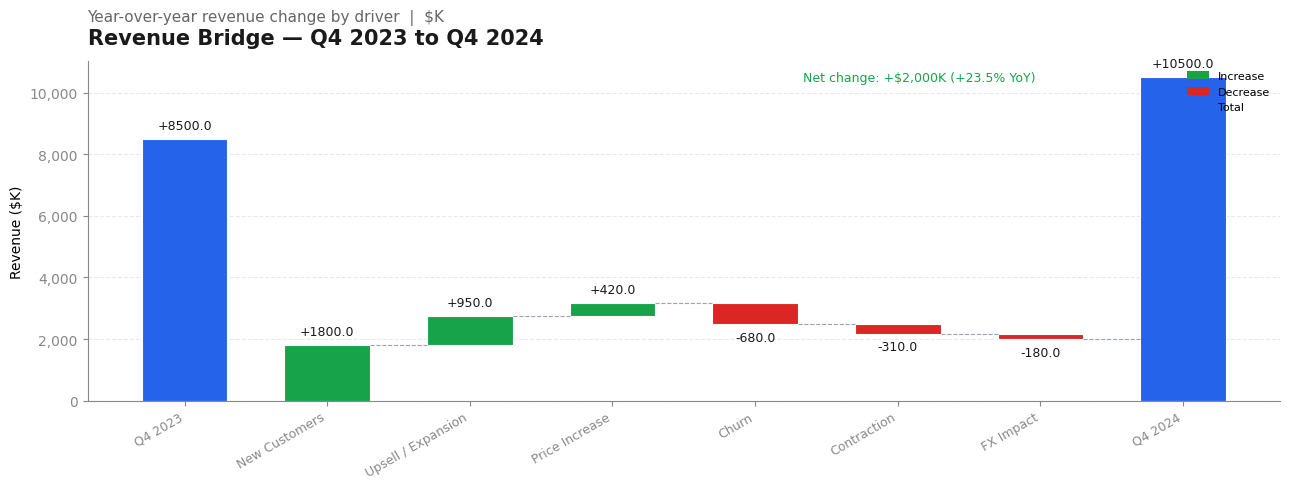

In [3]:
chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('Revenue Bridge — Q4 2023 to Q4 2024')
    .set_subtitle('Year-over-year revenue change by driver  |  $K')
    .build()
)
ax = chart.ax

waterfall_chart(
    ax,
    labels=revenue_bridge_labels,
    values=revenue_bridge_values,
    positive_color='#16A34A',
    negative_color='#DC2626',
    total_color='#2563EB',
    total_indices=[0, 7],      # first and last are totals
    bar_width=0.6,
    show_values=True,
    value_fontsize=9,
    connector_color='#9CA3AF',
)

format_thousands(ax, 'y')
ax.set_ylabel('Revenue ($K)')

# Net change annotation
net_change = ending - revenue_bridge_values[0]
pct_change = net_change / revenue_bridge_values[0] * 100
add_note(
    ax,
    f'Net change: +${net_change:,.0f}K (+{pct_change:.1f}% YoY)',
    x=0.60, y=0.97,
    color='#16A34A' if net_change >= 0 else '#DC2626',
    fontsize=9,
)

plt.tight_layout()
plt.show()

---
## 2. Waterfall Variants — P&L Bridge

Waterfall có nhiều ứng dụng:
- **Revenue bridge** — YoY driver analysis
- **P&L bridge** — từ Revenue xuống Net Income qua các cost line
- **Budget variance** — actual vs budget by category
- **Cash flow** — operating + investing + financing → ending cash

Khi có **subtotals** (Gross Profit, EBIT), dùng `total_indices` để đánh dấu —
các bar này sẽ được vẽ từ 0, không phải từ running total.

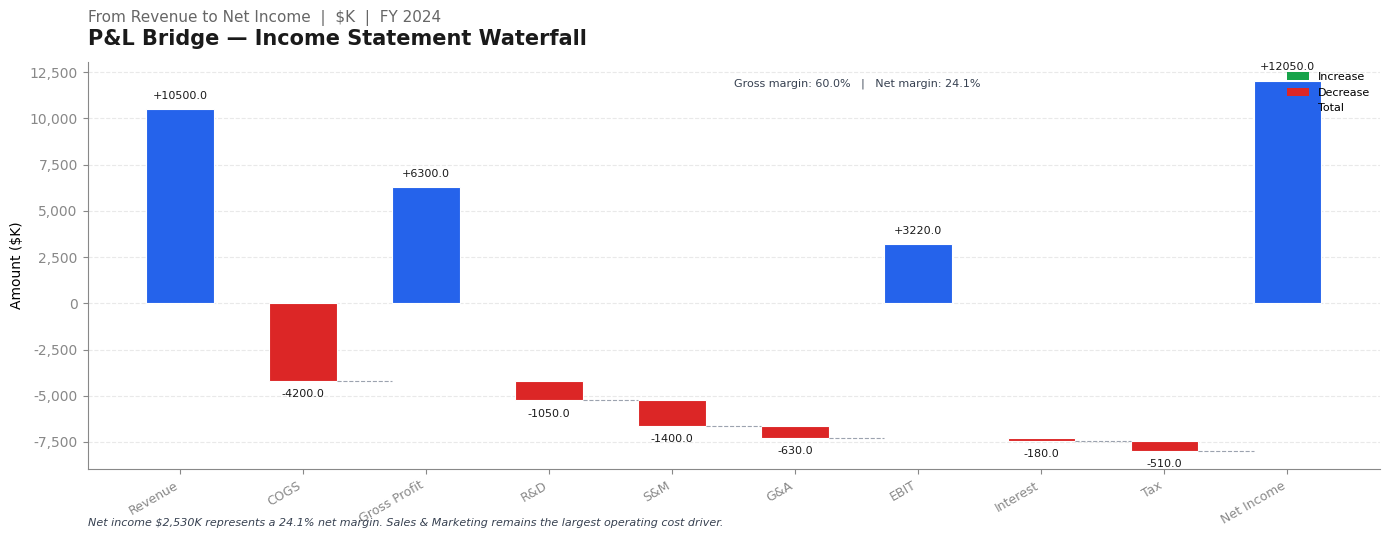

In [4]:
chart = (
    ChartBuilder(figsize=(14, 5.5))
    .set_title('P&L Bridge — Income Statement Waterfall')
    .set_subtitle('From Revenue to Net Income  |  $K  |  FY 2024')
    .build()
)
ax = chart.ax

waterfall_chart(
    ax,
    labels=pl_labels,
    values=pl_values,
    positive_color='#16A34A',
    negative_color='#DC2626',
    total_color='#2563EB',
    total_indices=pl_total_idx,
    bar_width=0.55,
    show_values=True,
    value_fontsize=8,
)

format_thousands(ax, 'y')
ax.set_ylabel('Amount ($K)')

# Net margin annotation
net_margin = pl_values[9] / pl_values[0] * 100
gross_margin = pl_values[2] / pl_values[0] * 100
add_note(
    ax,
    f'Gross margin: {gross_margin:.1f}%   |   Net margin: {net_margin:.1f}%',
    x=0.50, y=0.96,
    color='#374151', fontsize=8,
)

add_caption(
    ax,
    f'Net income ${pl_values[9]:,.0f}K represents a {net_margin:.1f}% net margin. '
    'Sales & Marketing remains the largest operating cost driver.',
    fontsize=CAPTION_SIZE,
)

plt.tight_layout()
plt.show()

---
## 3. Waterfall — Budget Variance

**Variance waterfall** so sánh actual vs budget — hiển thị từng dòng chi phí đang
favorable (dưới budget) hay unfavorable (vượt budget).

Convention trong finance:
- **Revenue variance**: Actual > Budget = **Favorable** (xanh)
- **Cost variance**: Actual < Budget = **Favorable** (xanh) — cost thấp hơn là tốt
- Total variance = tổng hợp tác động lên bottom line

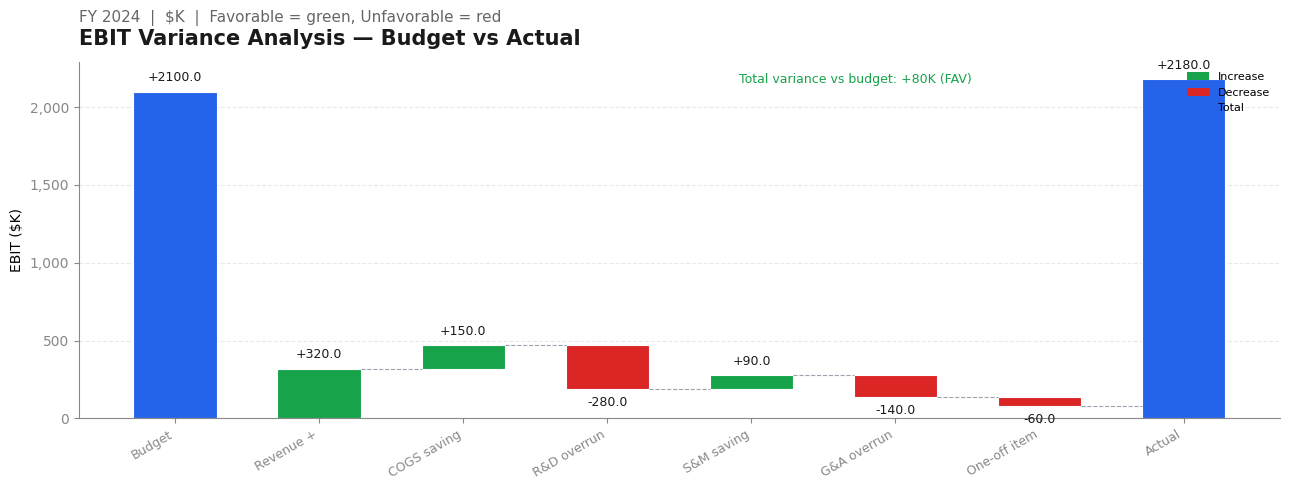

In [5]:
variance_labels = [
    'Budget',
    'Revenue +',
    'COGS saving',
    'R&D overrun',
    'S&M saving',
    'G&A overrun',
    'One-off item',
    'Actual',
]
variance_values = [
    2_100,   # Budget EBIT
    +320,    # Revenue beat
    +150,    # COGS below budget
    -280,    # R&D above budget
    +90,     # S&M below budget
    -140,    # G&A above budget
    -60,     # One-off restructuring
    0,       # Actual (computed)
]
variance_values[-1] = variance_values[0] + sum(variance_values[1:-1])

chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('EBIT Variance Analysis — Budget vs Actual')
    .set_subtitle('FY 2024  |  $K  |  Favorable = green, Unfavorable = red')
    .build()
)
ax = chart.ax

waterfall_chart(
    ax,
    labels=variance_labels,
    values=variance_values,
    positive_color='#16A34A',
    negative_color='#DC2626',
    total_color='#2563EB',
    total_indices=[0, 7],
    bar_width=0.58,
    show_values=True,
    value_fontsize=9,
)

format_thousands(ax, 'y')
ax.set_ylabel('EBIT ($K)')

net_var = variance_values[-1] - variance_values[0]
add_note(
    ax,
    f'Total variance vs budget: {"+" if net_var >= 0 else ""}{net_var:,.0f}K '
    f'({"FAV" if net_var >= 0 else "UNF"})',
    x=0.55, y=0.97,
    color='#16A34A' if net_var >= 0 else '#DC2626',
    fontsize=9,
)

plt.tight_layout()
plt.show()

---
## 4. Contribution Chart — Share of Total

**Contribution chart** (horizontal bar) trả lời câu hỏi:
*"Category nào chiếm nhiều nhất trong tổng?"*

Tại sao horizontal hơn vertical:
- Category labels thường dài — horizontal cho nhiều không gian hơn
- Mắt người dễ so sánh độ dài ngang hơn độ cao dọc
- Sorted order (lớn → nhỏ) tạo ranking tự nhiên từ trên xuống

`contribution_chart` tự động normalize về % và sort theo giá trị.

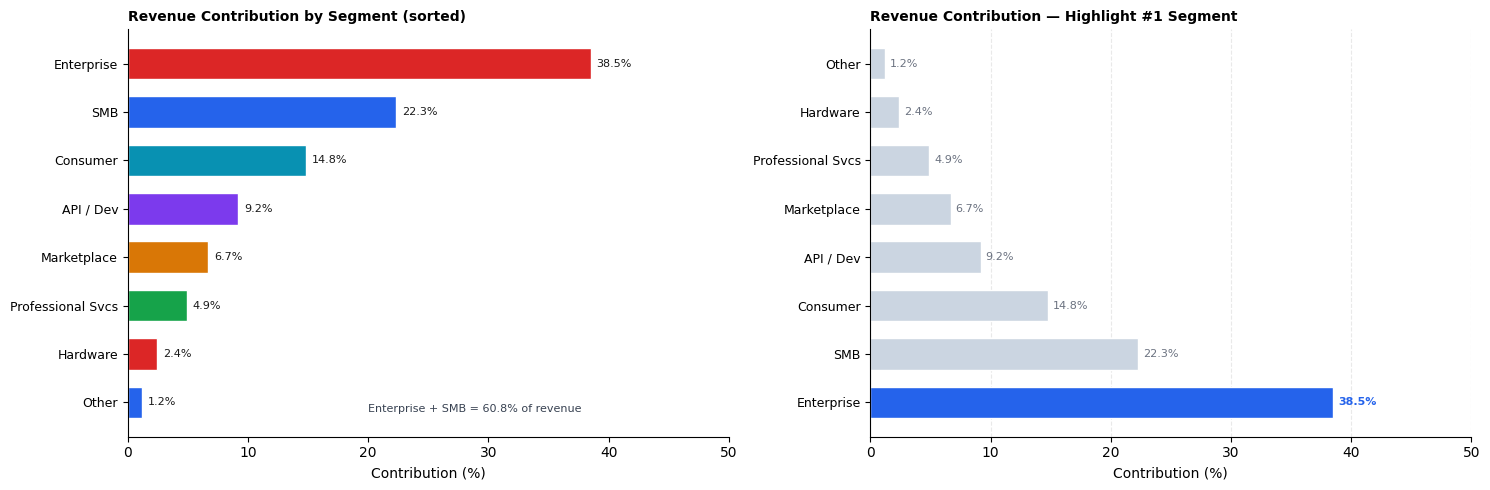

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Panel 1: Sorted (default)
ax = axes[0]
contribution_chart(
    ax,
    categories=products_contrib,
    contributions=contrib_values,
    palette='default',
    bar_height=0.65,
    show_values=True,
    value_fmt='{:.1f}%',
    sort=True,
)
ax.set_title('Revenue Contribution by Segment (sorted)',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlim(0, 50)
add_note(ax, 'Enterprise + SMB = 60.8% of revenue',
         x=0.40, y=0.08, color='#374151', fontsize=8)
despine(ax, left=False)

# Panel 2: Highlight top contributor
ax = axes[1]
cats_sorted = [x for _, x in sorted(
    zip(contrib_values, products_contrib), reverse=True
)]
vals_sorted = sorted(contrib_values, reverse=True)

bar_colors = ['#2563EB' if i == 0 else '#CBD5E1'
              for i in range(len(cats_sorted))]

y_pos = np.arange(len(cats_sorted))
ax.barh(y_pos, vals_sorted, height=0.65,
        color=bar_colors, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(cats_sorted, fontsize=9)

for i, v in enumerate(vals_sorted):
    ax.text(v + 0.4, i, f'{v:.1f}%',
            va='center', fontsize=8,
            color='#2563EB' if i == 0 else '#6B7280',
            fontweight='bold' if i == 0 else 'normal')

ax.set_xlabel('Contribution (%)')
ax.set_xlim(0, 50)
ax.set_title('Revenue Contribution — Highlight #1 Segment',
             loc='left', fontsize=10, fontweight='bold')
despine(ax, left=False); set_grid(ax, which='x')

plt.tight_layout()
plt.show()

---
## 5. Stacked Contribution Over Time

**Stacked area chart** = contribution chart theo thời gian.
Cho thấy:
- Tổng tăng trưởng qua thời gian
- Mỗi segment chiếm bao nhiêu % của tổng tại mỗi thời điểm
- Segment nào đang tăng / giảm tỷ trọng

Lưu ý: stacked area khó đọc khi có nhiều segment —
giới hạn ở 4-5 segment, group các category nhỏ thành "Other".

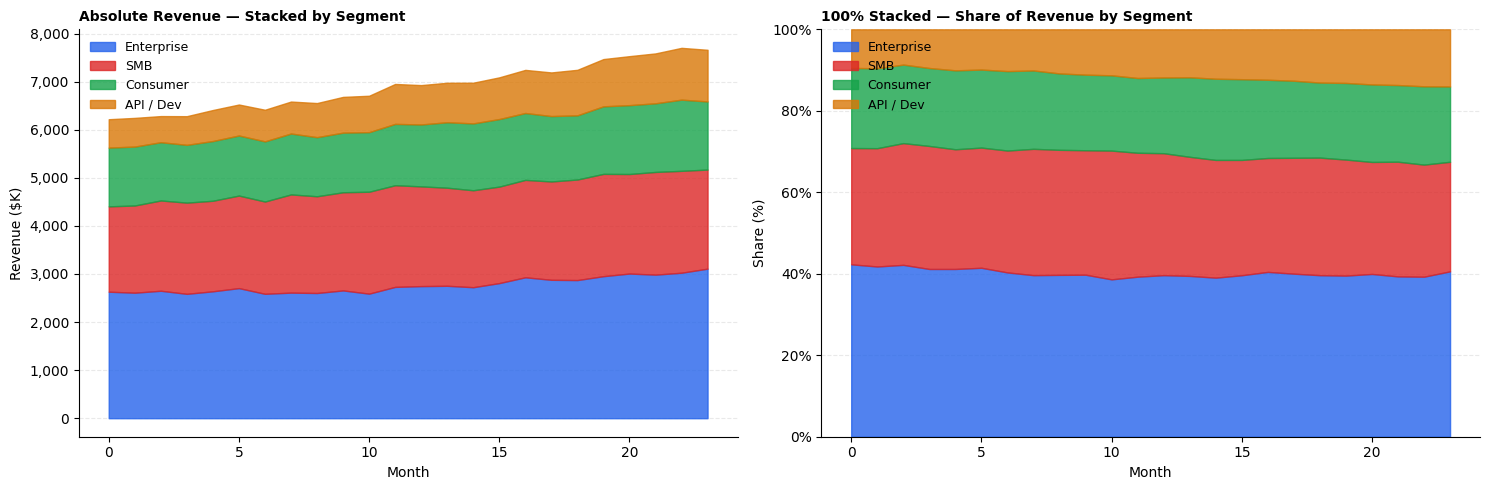

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Panel 1: Absolute stacked area
ax = axes[0]
stacked_contribution(
    ax,
    x=months_t,
    series=segment_series,
    palette='default',
    alpha=0.80,
    legend=True,
    legend_loc='upper left',
)
format_thousands(ax, 'y')
ax.set_title('Absolute Revenue — Stacked by Segment',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
despine(ax); set_grid(ax)

# Panel 2: 100% stacked (normalized)
ax = axes[1]
arrays = np.array(list(segment_series.values()))  # shape: (n_segments, T)
totals = arrays.sum(axis=0)  # shape: (T,)
normalized = {name: y / totals * 100
              for name, y in segment_series.items()}

stacked_contribution(
    ax,
    x=months_t,
    series=normalized,
    palette='default',
    alpha=0.80,
    legend=True,
    legend_loc='upper left',
)
ax.set_ylim(0, 100)
format_percent(ax, 'y', decimals=0)
ax.set_title('100% Stacked — Share of Revenue by Segment',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Share (%)')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 6. Time Series Decomposition

**Decomposition** tách một time series thành 3 thành phần:

| Component | Ý nghĩa | Câu hỏi trả lời |
|-----------|---------|------------------|
| **Trend** | Long-term direction | Tổng thể tăng hay giảm? |
| **Seasonal** | Periodic pattern | Có mùa vụ không? Biên độ là bao nhiêu? |
| **Residual** | What's left | Outlier ở đâu? Có shock bất thường không? |

Hai model:
- **Additive**: `Y = Trend + Seasonal + Residual` — khi biên độ mùa vụ không đổi theo trend
- **Multiplicative**: `Y = Trend × Seasonal × Residual` — khi biên độ mùa vụ tỷ lệ với trend

Dùng `statsmodels.tsa.seasonal.seasonal_decompose` bên trong.

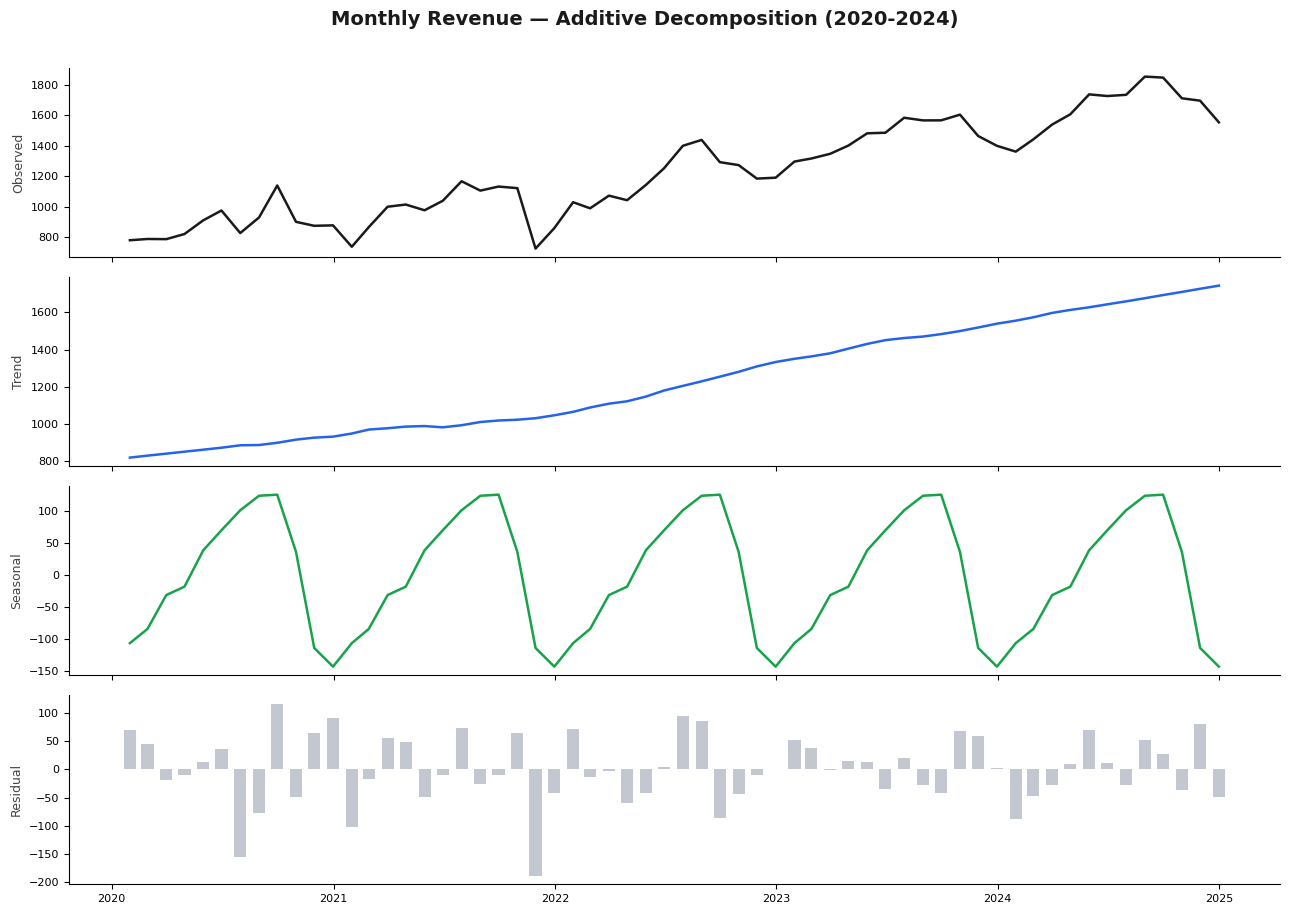

In [8]:
# Additive decomposition
fig = decomposition_chart(
    ts_series,
    period=12,
    model='additive',
    figsize=(13, 9),
    title='Monthly Revenue — Additive Decomposition (2020-2024)',
    trend_color='#2563EB',
    seasonal_color='#16A34A',
    residual_color='#9CA3AF',
    original_color='#1a1a1a',
)
plt.tight_layout()
plt.show()

---
## 7. Decomposition — Additive vs Multiplicative

Khi nào dùng additive vs multiplicative?

**Visual test:** nhìn vào seasonal component:
- Nếu biên độ seasonal **không đổi** khi trend tăng → **Additive**
- Nếu biên độ seasonal **lớn hơn** khi trend cao → **Multiplicative**

Dưới đây tạo 2 series để thấy rõ sự khác biệt.

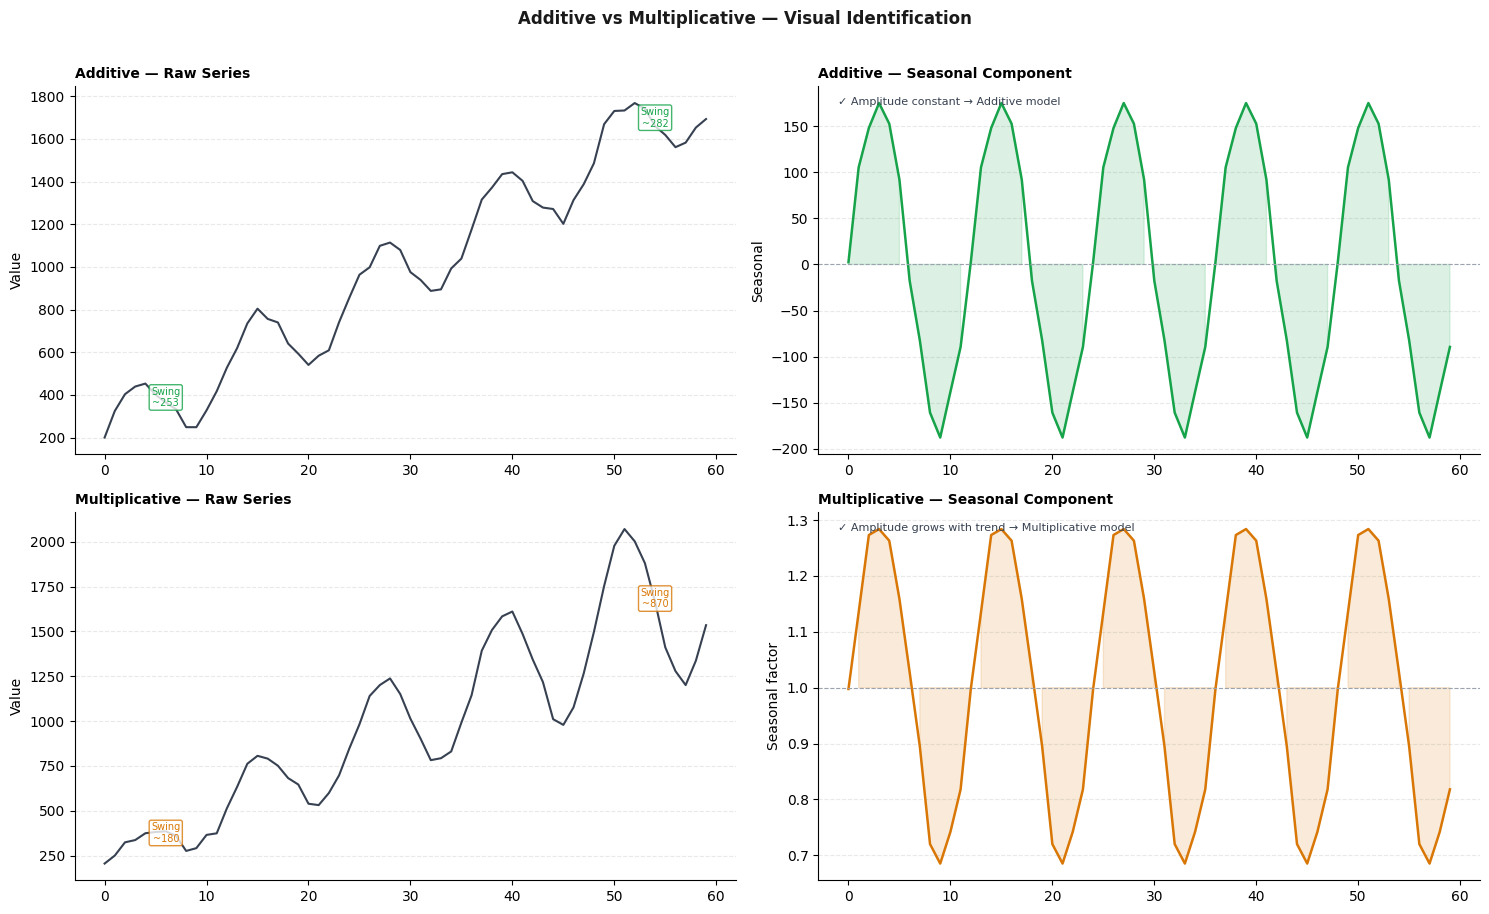

In [9]:
# Additive: seasonal amplitude CONSTANT regardless of trend level
# => biên độ mùa vụ đầu series = cuối series
t_arr     = np.arange(n_months)
trend_add = np.linspace(200, 1800, n_months)   # steep trend để contrast rõ
seasonal_const = 180 * np.sin(2 * np.pi * t_arr / 12)   # fixed ±180
rng = np.random.default_rng(7)
y_add = pd.Series(
    trend_add + seasonal_const + rng.normal(0, 25, n_months),
    index=idx,
)

# Multiplicative: seasonal amplitude GROWS with trend
# => biên độ mùa vụ cuối series lớn hơn nhiều so với đầu
seasonal_factor = 1 + 0.30 * np.sin(2 * np.pi * t_arr / 12)  # ±30% of trend
y_mul = pd.Series(
    trend_add * seasonal_factor + rng.normal(0, 25, n_months),
    index=idx,
)

from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(2, 2, figsize=(15, 9), facecolor='white')

for row, (y_ts, model, title_prefix, color) in enumerate([
    (y_add, 'additive',       'Additive',        '#16A34A'),
    (y_mul, 'multiplicative', 'Multiplicative',  '#D97706'),
]):
    result = seasonal_decompose(y_ts, model=model, period=12,
                                extrapolate_trend='freq')
    seasonal_vals = result.seasonal.values

    # ── Left: Raw series ──────────────────────────────────────────────────
    ax = axes[row][0]
    ax.plot(t_arr, y_ts.values, color='#374151', linewidth=1.5)

    # Annotate early vs late peak-to-trough swing
    early_swing = y_ts.values[:12].max() - y_ts.values[:12].min()
    late_swing  = y_ts.values[-12:].max() - y_ts.values[-12:].min()
    ax.annotate(f'Swing\n~{early_swing:.0f}',
                xy=(6, y_ts.values[:12].mean()),
                fontsize=7, color=color, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8))
    ax.annotate(f'Swing\n~{late_swing:.0f}',
                xy=(54, y_ts.values[-12:].mean()),
                fontsize=7, color=color, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8))

    ax.set_title(f'{title_prefix} — Raw Series',
                 loc='left', fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')
    despine(ax); set_grid(ax)

    # ── Right: Seasonal component ─────────────────────────────────────────
    ax = axes[row][1]
    baseline = 0 if model == 'additive' else 1
    ax.plot(t_arr, seasonal_vals, color=color, linewidth=1.8)
    ax.axhline(baseline, color='#9CA3AF', linewidth=0.8, linestyle='--')
    ax.fill_between(t_arr, seasonal_vals, baseline,
                    where=(seasonal_vals > baseline), color=color, alpha=0.15)
    ax.fill_between(t_arr, seasonal_vals, baseline,
                    where=(seasonal_vals < baseline), color=color, alpha=0.15)

    ax.set_title(f'{title_prefix} — Seasonal Component',
                 loc='left', fontsize=10, fontweight='bold')
    ax.set_ylabel('Seasonal' if model == 'additive' else 'Seasonal factor')

    insight = ('✓ Amplitude constant → Additive model' if model == 'additive'
               else '✓ Amplitude grows with trend → Multiplicative model')
    add_note(ax, insight, x=0.03, y=0.97, color='#374151', fontsize=8)
    despine(ax); set_grid(ax)

fig.suptitle('Additive vs Multiplicative — Visual Identification',
             fontsize=12, fontweight='bold', color='#1a1a1a', y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Reading Residuals — Anomaly Detection

**Residual** = phần còn lại sau khi đã loại bỏ trend và seasonality.

Residual có giá trị lớn (|residual| >> σ) = tín hiệu có gì đó bất thường tại thời điểm đó:
- Outlier trong data (data quality issue)
- Sự kiện đặc biệt (COVID, policy shock, product launch)
- Model không phù hợp (trend model sai)

Đây là ứng dụng thực tế của decomposition trong anomaly detection.

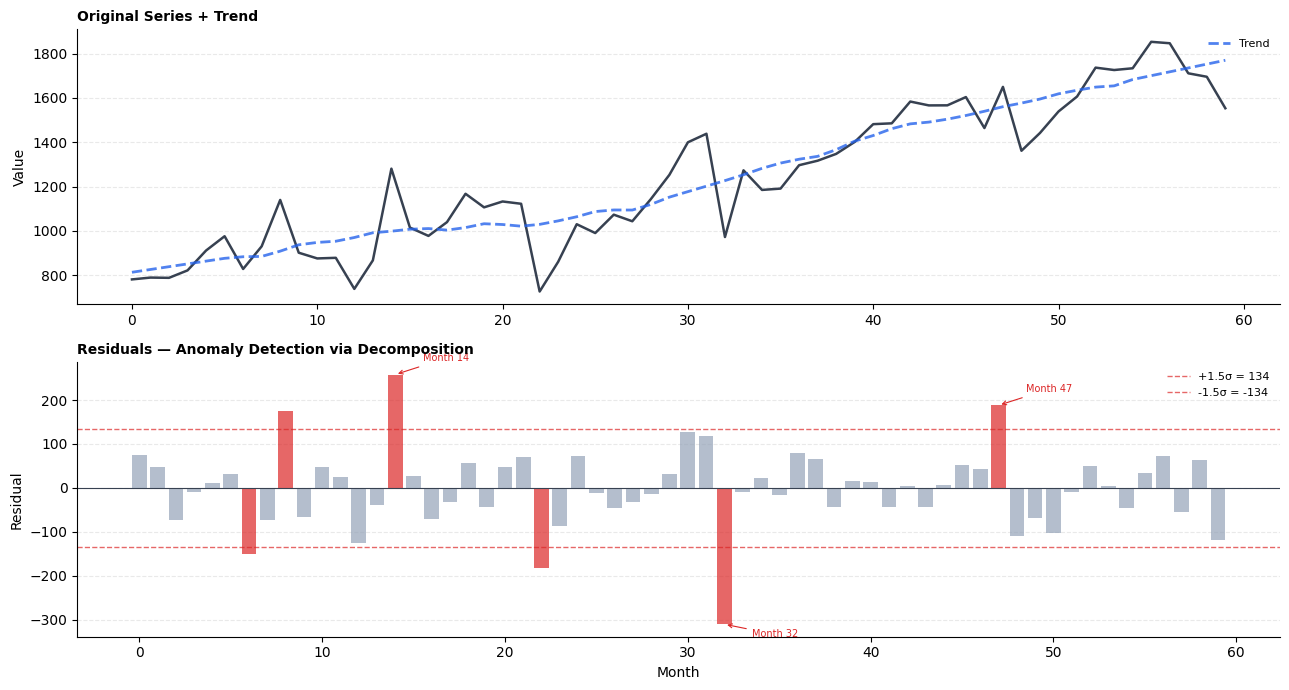

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from vizint.perception.outlier import detect_and_mark_outliers, emphasize_outliers

# Inject anomalies into ts_series
ts_with_anomaly = ts_series.copy()
anomaly_months = [14, 32, 47]   # inject shocks
ts_with_anomaly.iloc[anomaly_months] += np.array([280, -320, 250])

# Decompose
result = seasonal_decompose(ts_with_anomaly, model='additive',
                            period=12, extrapolate_trend='freq')
residuals = result.resid.values
t_arr_plot = np.arange(len(residuals))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), facecolor='white')

# Panel 1: Original series with anomalies
ax = axes[0]
ax.plot(t_arr_plot, ts_with_anomaly.values,
        color='#374151', linewidth=1.8)
ax.plot(t_arr_plot, result.trend.values,
        color='#2563EB', linewidth=2.0, linestyle='--',
        label='Trend', alpha=0.8)
ax.set_title('Original Series + Trend',
             loc='left', fontsize=10, fontweight='bold')
ax.legend(frameon=False, fontsize=8)
ax.set_ylabel('Value')
despine(ax); set_grid(ax)

# Panel 2: Residuals with outlier detection
ax = axes[1]
ax.bar(t_arr_plot, residuals,
       color=['#DC2626' if abs(r) > 1.5 * np.nanstd(residuals) else '#94A3B8'
              for r in residuals],
       width=0.8, alpha=0.7)
ax.axhline(0, color='#374151', linewidth=0.8)

# Threshold lines (±1.5σ)
sig = np.nanstd(residuals)
ax.axhline(+1.5 * sig, color='#DC2626', linewidth=1.0,
           linestyle='--', alpha=0.7, label=f'+1.5σ = {1.5*sig:.0f}')
ax.axhline(-1.5 * sig, color='#DC2626', linewidth=1.0,
           linestyle='--', alpha=0.7, label=f'-1.5σ = {-1.5*sig:.0f}')

# Annotate the 3 injected anomalies
for m in anomaly_months:
    ax.annotate(f'Month {m}',
                xy=(m, residuals[m]),
                xytext=(m + 1.5, residuals[m] + 30 * np.sign(residuals[m])),
                fontsize=7, color='#DC2626',
                arrowprops=dict(arrowstyle='->', color='#DC2626', lw=0.8))

ax.legend(frameon=False, fontsize=8)
ax.set_title('Residuals — Anomaly Detection via Decomposition',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Residual')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 9. Full Process Dashboard

Kết hợp waterfall + contribution + stacked area trong một layout 2×2 —
dashboard hoàn chỉnh cho một P&L review.

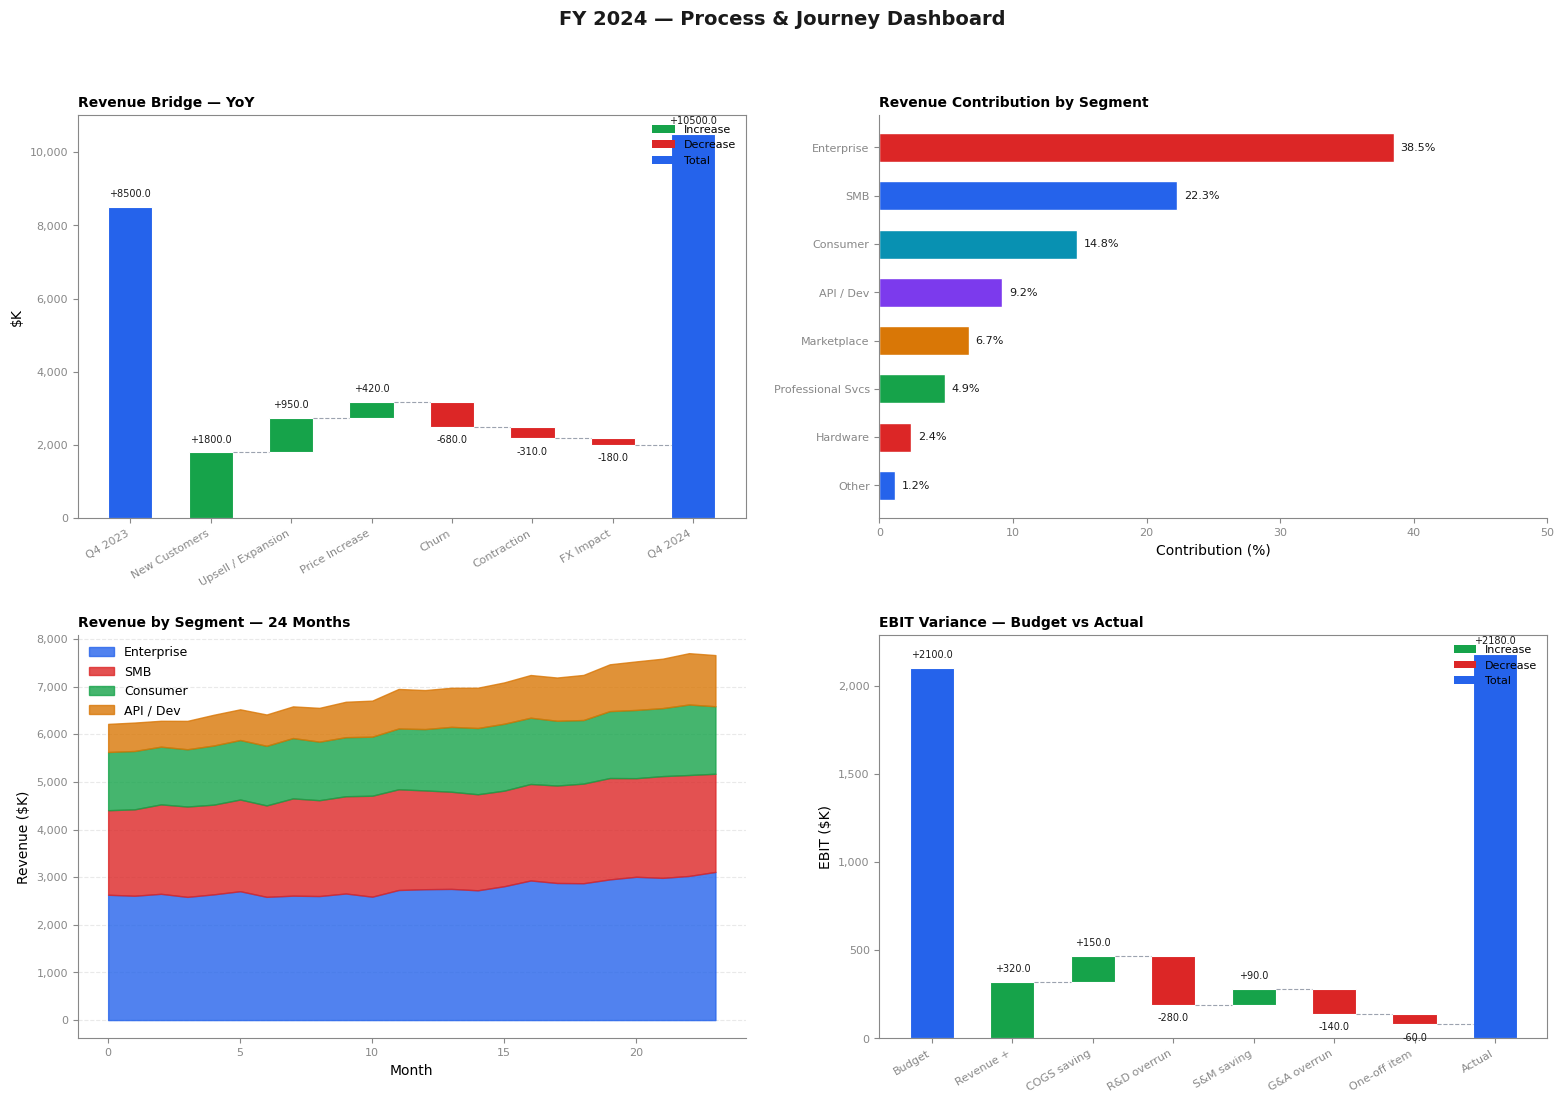

In [11]:
fig = plt.figure(figsize=(16, 11), facecolor='white')
fig.suptitle('FY 2024 — Process & Journey Dashboard',
             fontsize=14, fontweight='bold', color='#1a1a1a', y=1.01)

# Layout: 2 rows, 2 cols
ax1 = fig.add_subplot(2, 2, 1)   # Revenue bridge
ax2 = fig.add_subplot(2, 2, 2)   # P&L contribution
ax3 = fig.add_subplot(2, 2, 3)   # Stacked revenue over time
ax4 = fig.add_subplot(2, 2, 4)   # Budget variance

# ── Panel 1: Revenue Bridge ───────────────────────────────────────────────
waterfall_chart(
    ax1,
    labels=revenue_bridge_labels,
    values=revenue_bridge_values,
    positive_color='#16A34A', negative_color='#DC2626', total_color='#2563EB',
    total_indices=[0, 7], bar_width=0.55, show_values=True, value_fontsize=7,
)
ax1.set_title('Revenue Bridge — YoY', loc='left', fontsize=10, fontweight='bold')
format_thousands(ax1, 'y'); ax1.set_ylabel('$K')
set_tick_style(ax1, labelsize=8)

# ── Panel 2: Contribution ────────────────────────────────────────────────
contribution_chart(
    ax2,
    categories=products_contrib,
    contributions=contrib_values,
    palette='default',
    bar_height=0.60,
    show_values=True,
    value_fmt='{:.1f}%',
    sort=True,
)
ax2.set_title('Revenue Contribution by Segment', loc='left', fontsize=10, fontweight='bold')
ax2.set_xlim(0, 50)
set_tick_style(ax2, labelsize=8)
despine(ax2, left=False)

# ── Panel 3: Stacked area ────────────────────────────────────────────────
stacked_contribution(
    ax3,
    x=months_t,
    series=segment_series,
    palette='default',
    alpha=0.80,
    legend=True,
    legend_loc='upper left',
)
ax3.set_title('Revenue by Segment — 24 Months', loc='left', fontsize=10, fontweight='bold')
ax3.set_xlabel('Month'); ax3.set_ylabel('Revenue ($K)')
format_thousands(ax3, 'y')
despine(ax3); set_grid(ax3)
set_tick_style(ax3, labelsize=8)

# ── Panel 4: Budget Variance ─────────────────────────────────────────────
waterfall_chart(
    ax4,
    labels=variance_labels,
    values=variance_values,
    positive_color='#16A34A', negative_color='#DC2626', total_color='#2563EB',
    total_indices=[0, 7], bar_width=0.55, show_values=True, value_fontsize=7,
)
ax4.set_title('EBIT Variance — Budget vs Actual', loc='left', fontsize=10, fontweight='bold')
format_thousands(ax4, 'y'); ax4.set_ylabel('EBIT ($K)')
set_tick_style(ax4, labelsize=8)

plt.tight_layout(pad=2.0)
plt.show()

---
## Summary

| Technique | Function | Câu hỏi trả lời |
|-----------|----------|------------------|
| Waterfall — bridge | `waterfall_chart` | Từ A đến B qua những bước nào? |
| Waterfall — P&L | `waterfall_chart` (subtotals) | Revenue → Net Income |
| Waterfall — variance | `waterfall_chart` | Budget vs Actual từng dòng |
| Contribution bar | `contribution_chart` | Mỗi category = bao nhiêu % tổng? |
| Stacked area | `stacked_contribution` | Contribution thay đổi theo thời gian |
| 100% stacked | Normalize + `stacked_contribution` | Tỷ trọng thay đổi như thế nào? |
| Decomposition | `decomposition_chart` | Trend + Seasonal + Residual |
| Residual analysis | Manual (bar + thresholds) | Anomaly detection sau decompose |

---

### Key Takeaway

> Snapshot nói với bạn **bạn đang ở đâu**.
> Journey nói với bạn **làm thế nào bạn đến đây và điều gì đang thúc đẩy bạn**.
>
> Waterfall giải thích **change**. Contribution giải thích **composition**. Decomposition giải thích **structure**.
> Ba kỹ thuật này cùng nhau cho thấy toàn bộ câu chuyện đằng sau một con số.

**Next →** `07_framing_and_bias.ipynb` — Cùng một data, nhiều câu chuyện khác nhau: cách framing tạo ra bias và cách nhận diện / tránh nó.